# Atelier Preparation de Donnees Textuelles

## Partie 1 – Exploration du corpus

### 1) Charger les données CSV

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

df = pd.read_csv('../data/smart_reviews_raw.csv')
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,positif,5,fr


### 2) Combien d'avis contient le dataset ?

In [2]:
nb_avis = df.shape[0]
print(f"Le dataset contient {nb_avis} avis.")

Le dataset contient 1200 avis.


### 3) Combien de colonnes possède-t-il ?

In [3]:
nb_colonnes = df.shape[1]
print(f"Le dataset possède {nb_colonnes} colonnes : {list(df.columns)}")

Le dataset possède 8 colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### 4) Quel est le type de chaque colonne ?

In [4]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 5) Existe-t-il des valeurs manquantes ?

In [5]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

### 6) Identifier quelques types de texte

In [6]:
url_re = re.compile(r'https?://\S+|www\.\S+')
mention_re = re.compile(r'@\w+')
hashtag_re = re.compile(r'#\w+')
emoji_re = re.compile(r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]')
ponct_re = re.compile(r'[!?.,;:]{3,}')
repetition_re = re.compile(r'(.)\1{2,}')

texte_series = df['texte'].fillna('')

exemples = {
    'texte normal': texte_series[texte_series.str.match(r'^[A-Za-zÀ-ÿ ,.\'\-]+$', na=False)].iloc[0] if not texte_series[texte_series.str.match(r'^[A-Za-zÀ-ÿ ,.\'\-]+$', na=False)].empty else None,
    'texte vide': df.loc[df['texte'].isna() | (df['texte'].str.strip() == ''), 'texte'].iloc[0] if df['texte'].isna().any() else '(aucun trouve)',
    'texte avec URL': texte_series[texte_series.str.contains(url_re)].iloc[0],
    'texte avec mention': texte_series[texte_series.str.contains(mention_re)].iloc[0],
    'texte avec hashtag': texte_series[texte_series.str.contains(hashtag_re)].iloc[0],
    'texte avec emojis': texte_series[texte_series.str.contains(emoji_re)].iloc[0],
    'texte avec beaucoup de ponctuation': texte_series[texte_series.str.contains(ponct_re)].iloc[0],
    'texte en majuscules': texte_series[texte_series.str.isupper() & (texte_series.str.len() > 5)].iloc[0],
    'texte avec repetition de caracteres': texte_series[texte_series.str.contains(repetition_re)].iloc[0],
}

for cle, valeur in exemples.items():
    print(f"- {cle} : {valeur!r}")

- texte normal : 'Très  bonne  expérience,  simple  et  efficace.'
- texte vide : nan
- texte avec URL : 'Produit parfait, rien à signaler. https://example.com/commande/17'
- texte avec mention : '@client Livraison rapide et produit conforme à mes attentes.'
- texte avec hashtag : 'Très satisfait de mon achat 👍 #avis'
- texte avec emojis : 'Très satisfait de mon achat 👍 #avis'
- texte avec beaucoup de ponctuation : 'Produit excellent, je suis très satisfait. !!!'
- texte en majuscules : "LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."
- texte avec repetition de caracteres : 'Produit excellent, je suis très satisfait. !!!'


C:\Users\NGOM PC\AppData\Local\Temp\ipykernel_12872\2146999153.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'texte avec repetition de caracteres': texte_series[texte_series.str.contains(repetition_re)].iloc[0],


### 7) Longueur des textes

In [7]:
df['longueur'] = df['texte'].fillna('').str.len()

stats_longueur = {
    'min': df['longueur'].min(),
    'max': df['longueur'].max(),
    'moyenne': df['longueur'].mean(),
    'mediane': df['longueur'].median(),
    'Q1': df['longueur'].quantile(0.25),
    'Q3': df['longueur'].quantile(0.75),
}
for k, v in stats_longueur.items():
    print(f"{k} : {v:.2f}")

min : 0.00
max : 636.00
moyenne : 48.96
mediane : 48.00
Q1 : 37.00
Q3 : 56.00


### 8) Visualisation de la distribution de la longueur des avis

C:\Users\NGOM PC\AppData\Local\Temp\ipykernel_12872\1971241726.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['longueur'], vert=True)


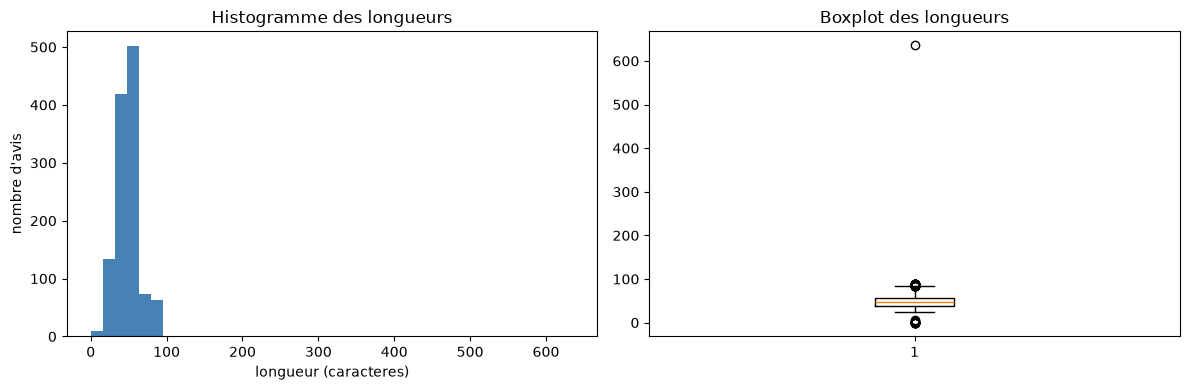

Nombre de textes au-dela du 99e percentile (87 caracteres) : 11
Nombre de textes tres courts (< 10 caracteres) : 9


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['longueur'], bins=40, color='steelblue')
axes[0].set_title('Histogramme des longueurs')
axes[0].set_xlabel('longueur (caracteres)')
axes[0].set_ylabel("nombre d'avis")

axes[1].boxplot(df['longueur'], vert=True)
axes[1].set_title('Boxplot des longueurs')
plt.tight_layout()
plt.show()

seuil_long = df['longueur'].quantile(0.99)
seuil_court = 10
nb_longs = (df['longueur'] > seuil_long).sum()
nb_courts = (df['longueur'] < seuil_court).sum()
print(f"Nombre de textes au-dela du 99e percentile ({seuil_long:.0f} caracteres) : {nb_longs}")
print(f"Nombre de textes tres courts (< {seuil_court} caracteres) : {nb_courts}")

**a) Existe-t-il des textes anormalement longs ?**
Oui. La majorite des avis se situe entre 37 et 56 caracteres (Q1/Q3), mais le maximum atteint 636 caracteres et 11 avis depassent le 99e percentile (87 caracteres) : ce sont des valeurs aberrantes tres eloignees de la distribution generale, a surveiller lors du nettoyage.

**b) Existe-t-il beaucoup de textes tres courts ?**
Oui, dans une moindre mesure : 9 avis ont moins de 10 caracteres (dont les textes vides). Cela reste marginal (moins de 1% du corpus) mais ces avis tres courts risquent de porter peu d'information utile pour la classification de sentiment.

### 9) Detection des textes vides

In [9]:
textes_vides = df[df['texte'].isna() | (df['texte'].fillna('').str.strip() == '')]
print(f"Nombre de textes vides ou manquants : {len(textes_vides)}")
textes_vides[['id_avis', 'texte', 'sentiment']]

Nombre de textes vides ou manquants : 6


,id_avis,texte,sentiment
46,AV0047,NaN,positif
108,AV0109,NaN,positif
310,AV0311,NaN,positif
640,AV0641,NaN,positif
781,AV0782,NaN,neutre
951,AV0952,,positif


### 10) Detection des doublons sur le texte

In [10]:
doublons = df[df.duplicated(subset='texte', keep=False) & df['texte'].notna()].sort_values('texte')
print(f"Nombre de lignes impliquees dans un doublon de texte : {len(doublons)}")
print(f"Nombre de doublons (lignes en trop) : {df.duplicated(subset='texte').sum()}")
doublons[['id_avis', 'texte']].head(10)

Nombre de lignes impliquees dans un doublon de texte : 1031
Nombre de doublons (lignes en trop) : 881


,id_avis,texte
312,AV0313,@client Excellent rapport qualité-prix.
419,AV0420,@client Excellent rapport qualité-prix.
1099,AV1100,@client Excellent rapport qualité-prix.
45,AV0046,@client Excellent rapport qualité-prix.
466,AV0467,@client Excellent rapport qualité-prix.
1059,AV1060,@client Excellent rapport qualité-prix.
146,AV0147,@client Excellent rapport qualité-prix.
593,AV0594,@client Excellent rapport qualité-prix.
611,AV0612,@client Excellent rapport qualité-prix.
398,AV0399,@client Excellent rapport qualité-prix.


### 11) Les classes sont-elles equilibrees ?

In [11]:
repartition = df['sentiment'].value_counts()
proportions = df['sentiment'].value_counts(normalize=True) * 100
print(repartition)
print()
print(proportions.round(2))

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64


Non, les classes ne sont pas equilibrees : `positif` represente 64.67% des avis (776), `neutre` 20.50% (246) et `negatif` 14.83% (178). La classe positive domine tres largement, ce qui constitue un desequilibre significatif a prendre en compte pour la modelisation et l'evaluation.

### 12) Quelle est la classe majoritaire ?

In [12]:
classe_majoritaire = df['sentiment'].value_counts().idxmax()
print(f"La classe majoritaire est : {classe_majoritaire}")

La classe majoritaire est : positif


### 13) Quelles metriques de classification envisager ?

In [13]:
baseline_accuracy = (df['sentiment'] == 'positif').mean()
print(f"Un modele qui predit toujours 'positif' obtiendrait une accuracy de {baseline_accuracy:.2%} sans rien avoir appris.")

Un modele qui predit toujours 'positif' obtiendrait une accuracy de 64.67% sans rien avoir appris.

Le jeu de donnees etant desequilibre (64.67% de `positif`), l'**accuracy seule est trompeuse** : un modele naif qui predit toujours la classe majoritaire obtient deja ~65% d'accuracy. Il faut donc privilegier :
- le **F1-score macro** (moyenne non ponderee des F1 par classe), qui penalise un modele incapable de detecter les classes minoritaires (`negatif`, `neutre`) ;
- la **precision** et le **rappel par classe**, pour savoir si le modele confond `neutre` et `negatif` avec `positif` ;
- la **matrice de confusion**, pour visualiser les erreurs entre classes ;
- eventuellement le **F1-score pondere** (weighted) pour une vue globale tenant compte du poids reel des classes.

### 14) Detection des caracteres particuliers

In [14]:
chiffres_re = re.compile(r'\d')
speciaux_re = re.compile(r'[^\w\s.,!?\'\-]', flags=re.UNICODE)

compteurs = {
    'emojis': texte_series.str.contains(emoji_re).sum(),
    'URLs': texte_series.str.contains(url_re).sum(),
    'hashtags': texte_series.str.contains(hashtag_re).sum(),
    'mentions': texte_series.str.contains(mention_re).sum(),
    'chiffres': texte_series.str.contains(chiffres_re).sum(),
    'caracteres speciaux': texte_series.str.contains(speciaux_re).sum(),
    'ponctuation repetee (!!!, ???, ...)': texte_series.str.contains(ponct_re).sum(),
}
for cle, valeur in compteurs.items():
    print(f"{cle} : {valeur} avis concernes")

emojis : 192 avis concernes
URLs : 143 avis concernes
hashtags : 127 avis concernes
mentions : 128 avis concernes
chiffres : 142 avis concernes
caracteres speciaux : 569 avis concernes
ponctuation repetee (!!!, ???, ...) : 141 avis concernes


### 15) Nombre d'avis par source

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


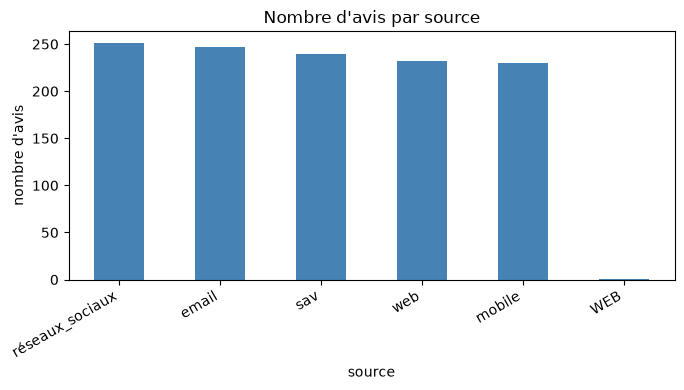

In [15]:
avis_par_source = df['source'].value_counts()
print(avis_par_source)

avis_par_source.plot(kind='bar', color='steelblue', figsize=(7, 4), title="Nombre d'avis par source")
plt.ylabel("nombre d'avis")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Les avis sont repartis de facon assez homogene entre les 5 sources (entre 230 et 251 avis chacune), sans source dominante. On note toutefois une incoherence de qualite : la valeur `WEB` (en majuscules, 1 occurrence) est en realite un doublon de categorie avec `web` du a une mauvaise normalisation de la casse a la collecte, et devra etre corrigee.

### 16) Nombre d'avis par produit

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


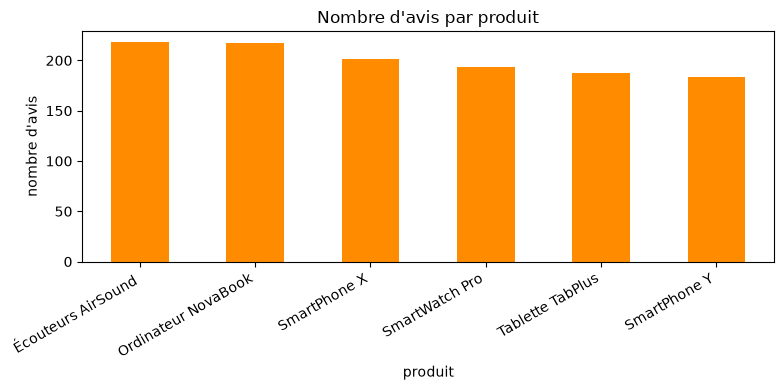

In [16]:
avis_par_produit = df['produit'].value_counts()
print(avis_par_produit)

avis_par_produit.plot(kind='bar', color='darkorange', figsize=(8, 4), title="Nombre d'avis par produit")
plt.ylabel("nombre d'avis")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

La repartition par produit est relativement equilibree (entre 184 et 218 avis par produit), sans produit sur- ou sous-represente de maniere problematique. Aucune correction n'est necessaire sur cette dimension.

## Partie 2 – Nettoyage

### 1) Suppression des lignes contenant des valeurs manquantes de texte

In [17]:
avant = len(df)
df = df[df['texte'].notna() & (df['texte'].str.strip() != '')].copy()
apres = len(df)
print(f"Lignes avant : {avant} | apres suppression des textes manquants/vides : {apres} | supprimees : {avant - apres}")

Lignes avant : 1200 | apres suppression des textes manquants/vides : 1194 | supprimees : 6


### 2) Suppression des doublons

In [18]:
avant = len(df)
df = df.drop_duplicates(subset='texte').copy()
apres = len(df)
print(f"Lignes avant : {avant} | apres suppression des doublons : {apres} | supprimees : {avant - apres}")

Lignes avant : 1194 | apres suppression des doublons : 317 | supprimees : 877


### 3) Suppression des URLs

In [19]:
nb_urls = df['texte'].str.contains(url_re).sum()
df['texte_clean'] = df['texte'].str.replace(url_re, ' ', regex=True)
print(f"URLs supprimees dans {nb_urls} avis.")
df.loc[df['texte'].str.contains(url_re), ['texte', 'texte_clean']].head(3)

URLs supprimees dans 143 avis.


,texte,texte_clean
16,"Produit parfait, rien à signaler. https://example.com/commande/17","Produit parfait, rien à signaler."
30,"Très bonne expérience, simple et efficace. https://example.com/commande/31","Très bonne expérience, simple et efficace."
31,"Je viens de recevoir le produit, à voir dans le temps. https://example.com/commande/32","Je viens de recevoir le produit, à voir dans le temps."


### 4) Traitement des mentions et hashtags

Strategie retenue : les **mentions** (`@client`, `@support`, ...) sont des identifiants sans charge sentimentale : elles sont **supprimees**. Les **hashtags** (`#avis`, `#decu`, ...) peuvent au contraire porter un mot cle utile au sentiment : seul le symbole `#` est retire, le mot est **conserve**.

In [20]:
avant_mentions = df['texte_clean'].str.contains(mention_re).sum()
avant_hashtags = df['texte_clean'].str.contains(hashtag_re).sum()

df['texte_clean'] = df['texte_clean'].str.replace(mention_re, ' ', regex=True)
df['texte_clean'] = df['texte_clean'].str.replace('#', '', regex=False)

print(f"Mentions supprimees dans {avant_mentions} avis ; symbole # retire dans {avant_hashtags} avis (mot conserve).")
df.loc[df['texte'].str.contains(mention_re) | df['texte'].str.contains(hashtag_re), ['texte', 'texte_clean']].head(5)

Mentions supprimees dans 24 avis ; symbole # retire dans 25 avis (mot conserve).


,texte,texte_clean
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
9,@client Livraison rapide et produit conforme à mes attentes.,Livraison rapide et produit conforme à mes attentes.
12,La batterie tient vraiment bien et l'écran est superbe. #avis,La batterie tient vraiment bien et l'écran est superbe. avis
15,Produit correct pour son prix. #avis,Produit correct pour son prix. avis
32,@client Service client réactif et commande reçue rapidement.,Service client réactif et commande reçue rapidement.


### 5) Nettoyage des espaces

In [21]:
espaces_multiples_re = re.compile(r'\s+')
df['texte_clean'] = df['texte_clean'].str.replace(espaces_multiples_re, ' ', regex=True).str.strip()
df[['texte', 'texte_clean']].head(5)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat 👍 avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !!!"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.


### 6) Traitement de la ponctuation

Strategie retenue : la ponctuation d'emphase (`!`, `?`) est **conservee mais reduite a une seule occurrence** (`!!!` -> `!`) car elle porte une information d'intensite emotionnelle utile a la classification de sentiment. Les autres caracteres speciaux non porteurs de sens (symboles isoles, etc.) sont supprimes.

In [22]:
repetition_ponct_re = re.compile(r'([!?.,])\1+')
df['texte_clean'] = df['texte_clean'].str.replace(repetition_ponct_re, r'\1', regex=True)
df['texte_clean'] = df['texte_clean'].str.replace(speciaux_re, ' ', regex=True)
df['texte_clean'] = df['texte_clean'].str.replace(espaces_multiples_re, ' ', regex=True).str.strip()
df.loc[df['texte'].str.contains(ponct_re), ['texte', 'texte_clean']].head(5)

,texte,texte_clean
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !"
10,Très satisfait de mon achat 👍 !!!,Très satisfait de mon achat !
14,Qualité décevante pour ce prix. !!!,Qualité décevante pour ce prix. !
25,"Produit reçu endommagé, je suis mécontent. !!!","Produit reçu endommagé, je suis mécontent. !"
59,Le produit ne fonctionne déjà plus. !!!,Le produit ne fonctionne déjà plus. !


Note : le nettoyage des caracteres speciaux (regex `speciaux_re` deja definie en Partie 1) supprime au passage les emojis residuels, ceux-ci n'etant pas exploitables tels quels par les vectorisations Bag of Words / TF-IDF utilisees plus loin.

### 7) Fonction de nettoyage automatisant les actions ci-dessus

In [23]:
def nettoyer_texte(texte):
    """Applique URL/mentions/hashtags/ponctuation/espaces sur un texte brut."""
    if pd.isna(texte):
        return texte
    t = url_re.sub(' ', texte)
    t = mention_re.sub(' ', t)
    t = t.replace('#', '')
    t = repetition_ponct_re.sub(r'\1', t)
    t = speciaux_re.sub(' ', t)
    t = espaces_multiples_re.sub(' ', t).strip()
    return t

df['texte_clean_v2'] = df['texte'].apply(nettoyer_texte)
identique = (df['texte_clean_v2'] == df['texte_clean']).all()
print(f"La fonction reproduit exactement les traitements manuels precedents : {identique}")
df = df.drop(columns=['texte_clean_v2'])

La fonction reproduit exactement les traitements manuels precedents : True


### 8) Stockage des textes nettoyes dans la colonne texte_clean

In [24]:
print(f"Colonne texte_clean : {df['texte_clean'].notna().sum()} valeurs non nulles sur {len(df)} lignes.")
df[['id_avis', 'texte_clean']].head(3)

Colonne texte_clean : 317 valeurs non nulles sur 317 lignes.


,id_avis,texte_clean
0,AV0001,"Très bonne expérience, simple et efficace."
1,AV0002,Très satisfait de mon achat avis
2,AV0003,"Produit parfait, rien à signaler."


### 9) Verification texte vs texte_clean sur les 10 premieres observations

In [25]:
df[['texte', 'texte_clean']].head(10)

,texte,texte_clean
0,"Très bonne expérience, simple et efficace.","Très bonne expérience, simple et efficace."
1,Très satisfait de mon achat 👍 #avis,Très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.","Produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !!!","Produit excellent, je suis très satisfait. !"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.
5,Très satisfait de mon achat 👍 😊,Très satisfait de mon achat
6,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPIDEMENT.
7,Très satisfait de mon achat 👍,Très satisfait de mon achat
8,Le produit correspond globalement à la description.,Le produit correspond globalement à la description.
9,@client Livraison rapide et produit conforme à mes attentes.,Livraison rapide et produit conforme à mes attentes.


## Partie 3 – Tokenisation

### 1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?

In [26]:
exemple = df['texte_clean'].iloc[3]
print('Texte :', exemple)
print('split() :', exemple.split())

Texte : Produit excellent, je suis très satisfait. !
split() : ['Produit', 'excellent,', 'je', 'suis', 'très', 'satisfait.', '!']


`split()` decoupe uniquement sur les espaces : la ponctuation reste collee aux mots (`satisfait.` au lieu de `satisfait` + `.`), il ne gere pas les contractions (`l'ecran`), les nombres colles a du texte, ni les cas particuliers (guillemets, tirets, emojis). Un vrai tokenizer NLP (comme celui de NLTK) applique des regles linguistiques pour separer correctement mots et ponctuation, gerer les apostrophes et les cas ambigus (abreviations, nombres decimaux, etc.), ce que `split()` ne sait pas faire.

### 2) Tokenisation avec NLTK

In [27]:
from nltk.tokenize import word_tokenize

df['tokens'] = df['texte_clean'].apply(lambda t: word_tokenize(t, language='french'))
df['nb_tokens'] = df['tokens'].apply(len)

moyenne_tokens = df['nb_tokens'].mean()
idx_max = df['nb_tokens'].idxmax()
idx_min = df['nb_tokens'].idxmin()

print(f"a) Nombre de tokens (extrait) :\n{df['nb_tokens'].head()}")
print(f"\nb) Nombre moyen de tokens : {moyenne_tokens:.2f}")
print(f"\nc) Texte avec le plus de tokens ({df.loc[idx_max, 'nb_tokens']} tokens) :\n{df.loc[idx_max, 'texte_clean']}")
print(f"\nd) Texte avec le moins de tokens ({df.loc[idx_min, 'nb_tokens']} tokens) :\n{df.loc[idx_min, 'texte_clean']}")

a) Nombre de tokens (extrait) :
0     8
1     6
2     7
3     9
4    10
Name: nb_tokens, dtype: int64

b) Nombre moyen de tokens : 8.20

c) Texte avec le plus de tokens (144 tokens) :
Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue.

d) Texte avec le moins de tokens (1 tokens) :
OK


## Partie 4 – Normalisation

### 1) Uniformisation de la casse en minuscules

In [28]:
df['texte_norm'] = df['texte_clean'].str.lower()
df[['texte_clean', 'texte_norm']].head(5)

,texte_clean,texte_norm
0,"Très bonne expérience, simple et efficace.","très bonne expérience, simple et efficace."
1,Très satisfait de mon achat avis,très satisfait de mon achat avis
2,"Produit parfait, rien à signaler.","produit parfait, rien à signaler."
3,"Produit excellent, je suis très satisfait. !","produit excellent, je suis très satisfait. !"
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,la batterie tient vraiment bien et l'écran est superbe.


**Pourquoi ce traitement ?** Sans normalisation de la casse, un modele ou un vectoriseur (Bag of Words, TF-IDF) considere `Produit`, `PRODUIT` et `produit` comme 3 tokens differents, ce qui **dilue inutilement le vocabulaire** et disperse l'information statistique sur un meme mot. La mise en minuscules garantit que toutes les variantes de casse d'un mot sont comptees ensemble.

### 2) Faut-il systematiquement supprimer les accents dans un corpus francais ?

In [29]:
print('decevant/deçu ->', 'decevant' == 'décevant'.replace('é','e'))
exemple_accent = 'Produit décevant, je suis déçu.'
print('Avec accents :', exemple_accent)
print('Sans accents (naif) :', exemple_accent.replace('é', 'e').replace('è','e').replace('ç','c'))

decevant/deçu -> True
Avec accents : Produit décevant, je suis déçu.
Sans accents (naif) : Produit decevant, je suis decu.


Non, ce n'est pas recommande systematiquement. En francais, l'accent peut changer le sens ou la nature d'un mot (`ou`/`où`, `a`/`à`, `du`/`dû`) et sa suppression brutale cree parfois des collisions ou des mots incorrects. Ici, on **conserve les accents** : le corpus est propre (donnees informatiques, pas de fautes de saisie liees aux accents), et les etapes suivantes (stopwords, lemmatisation NLTK/French) fonctionnent avec des mots accentues. Supprimer les accents ne se justifierait que si le corpus contenait beaucoup de variantes non accentuees a normaliser (ex. saisie mobile, tweets).